# RELLIS-3D RGB Binary Ground / Non-ground Preprocessing

This notebook preprocesses **only the RGB camera images and colour semantic labels** from RELLIS-3D.

Output labels:

- `0`: non-ground
- `1`: ground
- `255`: ignore

Important mapping decisions:

- `water` → **non-ground**
- `puddle` → **ground**
- most terrain/surface materials → **ground**
- `void` and `sky` → **ignore**

The split is performed **by sequence** with a target ratio of **70% / 15% / 15%**, rather than randomly by frame, to reduce leakage between visually adjacent frames.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q pillow matplotlib pandas tqdm

## 1. Imports and path configuration

Change only `DRIVE_DATASET_ROOT` if your `RELLIS-3D` folder is stored elsewhere in Google Drive.

Expected structure:

```text
RELLIS-3D/
├── Rellis_3D_pylon_camera_node/
└── Rellis_3D_pylon_camera_node_label_color/
```

In [3]:
from pathlib import Path

# 示例：压缩包直接放在 MyDrive/IRP 文件夹中
ARCHIVE_PATH = Path(
    "/content/drive/MyDrive/IRP/RELLIS-3D.zip"
)

# 解压到 Colab 本地磁盘，读取速度更快
EXTRACT_DIR = Path("/content/RELLIS-3D")

print("Archive:", ARCHIVE_PATH)
print("Extract to:", EXTRACT_DIR)

if not ARCHIVE_PATH.exists():
    raise FileNotFoundError(
        f"Cannot find archive:\n{ARCHIVE_PATH}\n"
        "Please check the Google Drive path and filename."
    )

Archive: /content/drive/MyDrive/IRP/RELLIS-3D.zip
Extract to: /content/RELLIS-3D


In [4]:
import shutil

# 创建解压目录
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# 避免每次重新运行 notebook 都重复解压
extract_marker = EXTRACT_DIR / ".extract_complete"

if extract_marker.exists():
    print("Dataset has already been extracted.")
else:
    print("Extracting dataset...")

    archive_name = ARCHIVE_PATH.name.lower()

    if archive_name.endswith(".zip"):
        shutil.unpack_archive(
            str(ARCHIVE_PATH),
            str(EXTRACT_DIR),
            format="zip"
        )

    elif archive_name.endswith((".tar.gz", ".tgz")):
        shutil.unpack_archive(
            str(ARCHIVE_PATH),
            str(EXTRACT_DIR),
            format="gztar"
        )

    elif archive_name.endswith(".tar.bz2"):
        shutil.unpack_archive(
            str(ARCHIVE_PATH),
            str(EXTRACT_DIR),
            format="bztar"
        )

    elif archive_name.endswith(".tar.xz"):
        shutil.unpack_archive(
            str(ARCHIVE_PATH),
            str(EXTRACT_DIR),
            format="xztar"
        )

    elif archive_name.endswith(".tar"):
        shutil.unpack_archive(
            str(ARCHIVE_PATH),
            str(EXTRACT_DIR),
            format="tar"
        )

    else:
        raise ValueError(
            f"Unsupported archive format: {ARCHIVE_PATH.name}"
        )

    extract_marker.touch()
    print("Extraction completed.")

print(f"Dataset location: {EXTRACT_DIR}")

Extracting dataset...
Extraction completed.
Dataset location: /content/RELLIS-3D


In [5]:
def show_directory_tree(root: Path, max_depth: int = 3):
    root = root.resolve()

    for path in sorted(root.rglob("*")):
        try:
            depth = len(path.relative_to(root).parts)
        except ValueError:
            continue

        if depth <= max_depth:
            indent = "    " * (depth - 1)
            marker = "📁" if path.is_dir() else "📄"
            print(f"{indent}{marker} {path.name}")


show_directory_tree(EXTRACT_DIR, max_depth=3)

📄 .extract_complete
📁 RELLIS-3D
    📄 Rellis_3D_pylon_camera_node.zip
    📄 Rellis_3D_pylon_camera_node_label_color.zip


In [7]:
from pathlib import Path
import zipfile

INNER_ARCHIVE_ROOT = Path("/content/RELLIS-3D/RELLIS-3D")

IMAGE_ZIP = INNER_ARCHIVE_ROOT / "Rellis_3D_pylon_camera_node.zip"
LABEL_ZIP = INNER_ARCHIVE_ROOT / "Rellis_3D_pylon_camera_node_label_color.zip"

print("Image ZIP:", IMAGE_ZIP)
print("Label ZIP:", LABEL_ZIP)

if not IMAGE_ZIP.exists():
    raise FileNotFoundError(f"Cannot find image ZIP: {IMAGE_ZIP}")

if not LABEL_ZIP.exists():
    raise FileNotFoundError(f"Cannot find label ZIP: {LABEL_ZIP}")

Image ZIP: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node.zip
Label ZIP: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node_label_color.zip


In [8]:
def extract_zip(zip_path: Path, output_dir: Path):
    marker = output_dir / ".extract_complete"

    if marker.exists():
        print(f"Already extracted: {output_dir}")
        return

    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {zip_path.name}...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(output_dir)

    marker.touch()
    print(f"Completed: {output_dir}")


IMAGE_EXTRACT_DIR = INNER_ARCHIVE_ROOT / "Rellis_3D_pylon_camera_node"
LABEL_EXTRACT_DIR = INNER_ARCHIVE_ROOT / "Rellis_3D_pylon_camera_node_label_color"

extract_zip(IMAGE_ZIP, IMAGE_EXTRACT_DIR)
extract_zip(LABEL_ZIP, LABEL_EXTRACT_DIR)

Extracting Rellis_3D_pylon_camera_node.zip...
Completed: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node
Extracting Rellis_3D_pylon_camera_node_label_color.zip...
Completed: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node_label_color


In [9]:
def show_first_items(root: Path, max_items: int = 20):
    print(f"\nContents of: {root}")

    items = list(root.iterdir())

    for item in sorted(items)[:max_items]:
        item_type = "DIR " if item.is_dir() else "FILE"
        print(f"{item_type}: {item.name}")

    print(f"Total direct children: {len(items)}")


show_first_items(IMAGE_EXTRACT_DIR)
show_first_items(LABEL_EXTRACT_DIR)


Contents of: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node
FILE: .extract_complete
DIR : Rellis-3D
Total direct children: 2

Contents of: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node_label_color
FILE: .extract_complete
DIR : Rellis-3D
Total direct children: 2


In [10]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def find_actual_data_root(search_root: Path) -> Path:
    # 如果当前目录直接包含图像，则直接返回
    direct_images = [
        p for p in search_root.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if direct_images:
        return search_root

    # 否则寻找包含最多图像的子目录
    candidates = []

    for directory in [search_root] + [
        p for p in search_root.rglob("*") if p.is_dir()
    ]:
        image_count = sum(
            1
            for p in directory.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )

        if image_count > 0:
            candidates.append((image_count, directory))

    if not candidates:
        raise FileNotFoundError(
            f"No image files found under: {search_root}"
        )

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1]


ACTUAL_IMAGE_ROOT = find_actual_data_root(IMAGE_EXTRACT_DIR)
ACTUAL_LABEL_ROOT = find_actual_data_root(LABEL_EXTRACT_DIR)

print("Actual image root:", ACTUAL_IMAGE_ROOT)
print("Actual label root:", ACTUAL_LABEL_ROOT)

Actual image root: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node/Rellis-3D/00002/pylon_camera_node
Actual label root: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node_label_color/Rellis-3D/00002/pylon_camera_node_label_color


In [11]:

DATASET_ROOT = Path("/content/RELLIS-3D/RELLIS-3D")

IMAGE_ROOT = DATASET_ROOT / "Rellis_3D_pylon_camera_node"
LABEL_ROOT = DATASET_ROOT / "Rellis_3D_pylon_camera_node_label_color"

print("Dataset root:", DATASET_ROOT)
print("Image root:", IMAGE_ROOT)
print("Label root:", LABEL_ROOT)

Dataset root: /content/RELLIS-3D/RELLIS-3D
Image root: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node
Label root: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node_label_color


In [12]:
from pathlib import Path
from collections import Counter, defaultdict
import csv
import json
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

# Modify this path if necessary.
DRIVE_DATASET_ROOT = DATASET_ROOT

IMAGE_ROOT = DRIVE_DATASET_ROOT / 'Rellis_3D_pylon_camera_node'
MASK_ROOT = DRIVE_DATASET_ROOT / 'Rellis_3D_pylon_camera_node_label_color'

# Processed data are first written to Colab local storage for faster I/O.
PROCESSED_ROOT = Path('/content/RELLIS_3D_binary_processed')

# Final zip destination in Google Drive.
DRIVE_OUTPUT_DIR = Path('/content/drive/MyDrive/IRP')
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Dataset root:', DRIVE_DATASET_ROOT)
print('IMAGE_ROOT exists:', IMAGE_ROOT.exists(), IMAGE_ROOT)
print('MASK_ROOT exists:', MASK_ROOT.exists(), MASK_ROOT)

assert IMAGE_ROOT.exists(), f'Image folder not found: {IMAGE_ROOT}'
assert MASK_ROOT.exists(), f'Colour-label folder not found: {MASK_ROOT}'

Dataset root: /content/RELLIS-3D/RELLIS-3D
IMAGE_ROOT exists: True /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node
MASK_ROOT exists: True /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node_label_color


## 2. Inspect the raw directory structure

In [13]:
def print_tree(root: Path, max_depth=3, max_items=80):
    root = root.resolve()
    count = 0
    for path in sorted(root.rglob('*')):
        try:
            rel = path.relative_to(root)
        except ValueError:
            continue
        if len(rel.parts) > max_depth:
            continue
        suffix = '/' if path.is_dir() else ''
        print('  ' * (len(rel.parts) - 1) + rel.name + suffix)
        count += 1
        if count >= max_items:
            print('... output truncated ...')
            break

print('IMAGE_ROOT structure:')
print_tree(IMAGE_ROOT)
print('\nMASK_ROOT structure:')
print_tree(MASK_ROOT)

IMAGE_ROOT structure:
.extract_complete
Rellis-3D/
  00000/
    pylon_camera_node/
  00001/
    pylon_camera_node/
  00002/
    pylon_camera_node/
  00003/
    pylon_camera_node/
  00004/
    pylon_camera_node/

MASK_ROOT structure:
.extract_complete
Rellis-3D/
  00000/
    pylon_camera_node_label_color/
  00001/
    pylon_camera_node_label_color/
  00002/
    pylon_camera_node_label_color/
  00003/
    pylon_camera_node_label_color/
  00004/
    pylon_camera_node_label_color/


## 3. RELLIS-3D ontology and binary mapping

The colours below are read from the supplied RELLIS-3D ontology. PIL loads images in RGB order, so the hexadecimal colours are converted directly to `(R, G, B)` tuples.

In [14]:
IGNORE_INDEX = 255
NON_GROUND_ID = 0
GROUND_ID = 1

RELLIS_CLASSES = {
    0:  {'name': 'void',      'hex': '#000000', 'binary': IGNORE_INDEX},
    1:  {'name': 'dirt',      'hex': '#6c4014', 'binary': GROUND_ID},
    3:  {'name': 'grass',     'hex': '#006600', 'binary': GROUND_ID},
    4:  {'name': 'tree',      'hex': '#00ff00', 'binary': NON_GROUND_ID},
    5:  {'name': 'pole',      'hex': '#009999', 'binary': NON_GROUND_ID},
    6:  {'name': 'water',     'hex': '#0080ff', 'binary': NON_GROUND_ID},
    7:  {'name': 'sky',       'hex': '#0000ff', 'binary': IGNORE_INDEX},
    8:  {'name': 'vehicle',   'hex': '#ffff00', 'binary': NON_GROUND_ID},
    9:  {'name': 'object',    'hex': '#ff007f', 'binary': NON_GROUND_ID},
    10: {'name': 'asphalt',   'hex': '#404040', 'binary': GROUND_ID},
    12: {'name': 'building',  'hex': '#ff0000', 'binary': NON_GROUND_ID},
    15: {'name': 'log',       'hex': '#660000', 'binary': NON_GROUND_ID},
    17: {'name': 'person',    'hex': '#cc99ff', 'binary': NON_GROUND_ID},
    18: {'name': 'fence',     'hex': '#6600cc', 'binary': NON_GROUND_ID},
    19: {'name': 'bush',      'hex': '#ff99cc', 'binary': NON_GROUND_ID},
    23: {'name': 'concrete',  'hex': '#aaaaaa', 'binary': GROUND_ID},
    27: {'name': 'barrier',   'hex': '#2979ff', 'binary': NON_GROUND_ID},
    29: {'name': 'uphill',    'hex': '#651fff', 'binary': GROUND_ID},
    30: {'name': 'downhill',  'hex': '#899509', 'binary': GROUND_ID},
    31: {'name': 'puddle',    'hex': '#86ffef', 'binary': GROUND_ID},
    33: {'name': 'mud',       'hex': '#634222', 'binary': GROUND_ID},
    34: {'name': 'rubble',    'hex': '#6e168a', 'binary': NON_GROUND_ID},
}

def hex_to_rgb(hex_colour: str):
    h = hex_colour.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

RELLIS_COLOR_TO_ORIGINAL_ID = {
    hex_to_rgb(info['hex']): original_id
    for original_id, info in RELLIS_CLASSES.items()
}

RELLIS_COLOR_TO_BINARY_ID = {
    hex_to_rgb(info['hex']): info['binary']
    for info in RELLIS_CLASSES.values()
}

mapping_table = pd.DataFrame([
    {
        'original_id': original_id,
        'class_name': info['name'],
        'rgb': hex_to_rgb(info['hex']),
        'binary_id': info['binary'],
        'binary_class': (
            'ground' if info['binary'] == GROUND_ID else
            'non-ground' if info['binary'] == NON_GROUND_ID else
            'ignore'
        ),
    }
    for original_id, info in RELLIS_CLASSES.items()
]).sort_values('original_id').reset_index(drop=True)

mapping_table

,original_id,class_name,rgb,binary_id,binary_class
0,0,void,"(0, 0, 0)",255,ignore
1,1,dirt,"(108, 64, 20)",1,ground
2,3,grass,"(0, 102, 0)",1,ground
3,4,tree,"(0, 255, 0)",0,non-ground
4,5,pole,"(0, 153, 153)",0,non-ground
5,6,water,"(0, 128, 255)",0,non-ground
6,7,sky,"(0, 0, 255)",255,ignore
7,8,vehicle,"(255, 255, 0)",0,non-ground
8,9,object,"(255, 0, 127)",0,non-ground
9,10,asphalt,"(64, 64, 64)",1,ground


## 4. Colour mask conversion functions

Any colour not present in the ontology is assigned `255` and reported during validation.

In [15]:
def rgb_mask_to_original_id(mask_rgb: np.ndarray) -> np.ndarray:
    """Convert a RELLIS colour annotation to sparse original ontology IDs."""
    if mask_rgb.ndim != 3 or mask_rgb.shape[2] != 3:
        raise ValueError(f'Expected H x W x 3 RGB mask, got {mask_rgb.shape}')

    output = np.full(mask_rgb.shape[:2], IGNORE_INDEX, dtype=np.uint8)
    for colour, original_id in RELLIS_COLOR_TO_ORIGINAL_ID.items():
        matched = np.all(mask_rgb == np.asarray(colour, dtype=np.uint8), axis=-1)
        output[matched] = original_id
    return output


def rgb_mask_to_binary(mask_rgb: np.ndarray) -> np.ndarray:
    """Convert a RELLIS colour annotation to 0/1/255 binary labels."""
    if mask_rgb.ndim != 3 or mask_rgb.shape[2] != 3:
        raise ValueError(f'Expected H x W x 3 RGB mask, got {mask_rgb.shape}')

    output = np.full(mask_rgb.shape[:2], IGNORE_INDEX, dtype=np.uint8)
    for colour, binary_id in RELLIS_COLOR_TO_BINARY_ID.items():
        matched = np.all(mask_rgb == np.asarray(colour, dtype=np.uint8), axis=-1)
        output[matched] = binary_id
    return output


def unique_rgb_colours(mask_rgb: np.ndarray):
    return np.unique(mask_rgb.reshape(-1, 3), axis=0)

## 5. Collect and match image–mask pairs

The matcher supports `.jpg`, `.jpeg`, and `.png` camera images. It first tries the same relative path with different extensions, then falls back to matching by `(sequence, filename stem)`.

The sequence is defined as the first directory below `IMAGE_ROOT`. If files are stored directly in the root, all files are treated as one sequence; in that case sequence-level 70/15/15 splitting is not possible and the notebook stops with an explanatory error.

In [21]:
import re
from pathlib import Path
def sequence_name(path: Path, root: Path) -> str:
    """
    Extract the RELLIS-3D sequence name from a file path.

    Expected sequence directory names are typically:
        00000, 00001, 00002, ...

    The function searches all parent components of the relative path
    and returns the first five-digit directory name.
    """
    rel = path.relative_to(root)

    for part in rel.parts[:-1]:
        if re.fullmatch(r"\d{5}", part):
            return part

    raise ValueError(
        f"Could not identify a five-digit RELLIS-3D sequence "
        f"from relative path: {rel}"
    )

for path in image_files[:10]:
    print(
        path.relative_to(IMAGE_ROOT),
        "-> sequence:",
        sequence_name(path, IMAGE_ROOT)
    )

Rellis-3D/00000/pylon_camera_node/frame000000-1581624652_750.jpg -> sequence: 00000
Rellis-3D/00000/pylon_camera_node/frame000001-1581624652_849.jpg -> sequence: 00000
Rellis-3D/00000/pylon_camera_node/frame000002-1581624652_949.jpg -> sequence: 00000
Rellis-3D/00000/pylon_camera_node/frame000003-1581624653_049.jpg -> sequence: 00000
Rellis-3D/00000/pylon_camera_node/frame000004-1581624653_150.jpg -> sequence: 00000
Rellis-3D/00000/pylon_camera_node/frame000005-1581624653_249.jpg -> sequence: 00000
Rellis-3D/00000/pylon_camera_node/frame000006-1581624653_349.jpg -> sequence: 00000
Rellis-3D/00000/pylon_camera_node/frame000007-1581624653_449.jpg -> sequence: 00000
Rellis-3D/00000/pylon_camera_node/frame000008-1581624653_549.jpg -> sequence: 00000
Rellis-3D/00000/pylon_camera_node/frame000009-1581624653_649.jpg -> sequence: 00000


In [22]:
from collections import defaultdict

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
MASK_EXTENSIONS = {".png", ".jpg", ".jpeg"}


def list_files(root: Path, extensions):
    return sorted([
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in extensions
    ])


def pair_key(path: Path, root: Path):
    return sequence_name(path, root), path.stem


def collect_image_mask_pairs(image_root: Path, mask_root: Path):
    image_paths = list_files(image_root, IMAGE_EXTENSIONS)
    mask_paths = list_files(mask_root, MASK_EXTENSIONS)

    mask_index = defaultdict(list)

    for mask_path in mask_paths:
        key = pair_key(mask_path, mask_root)
        mask_index[key].append(mask_path)

    pairs = []
    missing = []
    ambiguous = []

    for image_path in image_paths:
        key = pair_key(image_path, image_root)
        candidates = mask_index.get(key, [])

        if len(candidates) == 1:
            pairs.append((image_path, candidates[0]))

        elif len(candidates) == 0:
            missing.append(image_path)

        else:
            ambiguous.append((image_path, candidates))

    print("Images found:", len(image_paths))
    print("Masks found: ", len(mask_paths))
    print("Matched pairs:", len(pairs))
    print("Missing masks:", len(missing))
    print("Ambiguous matches:", len(ambiguous))

    if missing:
        print("\nExamples of images without masks:")
        for path in missing[:10]:
            print(" ", path.relative_to(image_root))

    if ambiguous:
        print("\nExamples of ambiguous matches:")
        for image_path, candidates in ambiguous[:5]:
            print(
                image_path.relative_to(image_root),
                "->",
                [str(p.relative_to(mask_root)) for p in candidates]
            )

    return (
        sorted(pairs, key=lambda x: str(x[0])),
        missing,
        ambiguous,
    )


pairs, missing_images, ambiguous_pairs = collect_image_mask_pairs(
    IMAGE_ROOT,
    MASK_ROOT
)

assert len(pairs) > 0, "No image-mask pairs were found."
assert len(ambiguous_pairs) == 0, (
    "Ambiguous mask matches detected."
)

Images found: 13556
Masks found:  6234
Matched pairs: 6234
Missing masks: 7322
Ambiguous matches: 0

Examples of images without masks:
  Rellis-3D/00000/pylon_camera_node/frame000001-1581624652_849.jpg
  Rellis-3D/00000/pylon_camera_node/frame000003-1581624653_049.jpg
  Rellis-3D/00000/pylon_camera_node/frame000005-1581624653_249.jpg
  Rellis-3D/00000/pylon_camera_node/frame000007-1581624653_449.jpg
  Rellis-3D/00000/pylon_camera_node/frame000009-1581624653_649.jpg
  Rellis-3D/00000/pylon_camera_node/frame000011-1581624653_849.jpg
  Rellis-3D/00000/pylon_camera_node/frame000013-1581624654_049.jpg
  Rellis-3D/00000/pylon_camera_node/frame000015-1581624654_249.jpg
  Rellis-3D/00000/pylon_camera_node/frame000017-1581624654_449.jpg
  Rellis-3D/00000/pylon_camera_node/frame000019-1581624654_649.jpg


In [23]:
pairs_by_sequence = defaultdict(list)

for image_path, mask_path in pairs:
    seq = sequence_name(image_path, IMAGE_ROOT)
    pairs_by_sequence[seq].append((image_path, mask_path))

sequence_counts = {
    seq: len(items)
    for seq, items in pairs_by_sequence.items()
}

sequences = sorted(sequence_counts)

print("Number of sequences:", len(sequences))
print("Frames per sequence:")

for seq, count in sorted(sequence_counts.items()):
    print(f"  {seq}: {count}")

Number of sequences: 5
Frames per sequence:
  00000: 1200
  00001: 1161
  00002: 2074
  00003: 900
  00004: 899


## 6. Visual sanity check before processing

Image: Rellis-3D/00000/pylon_camera_node/frame000000-1581624652_750.jpg
Mask:  Rellis-3D/00000/pylon_camera_node_label_color/frame000000-1581624652_750.png
Image shape: (1200, 1920, 3)
Mask shape:  (1200, 1920, 3)
Binary values: [  0   1 255]
Unknown RGB colours in this mask: []


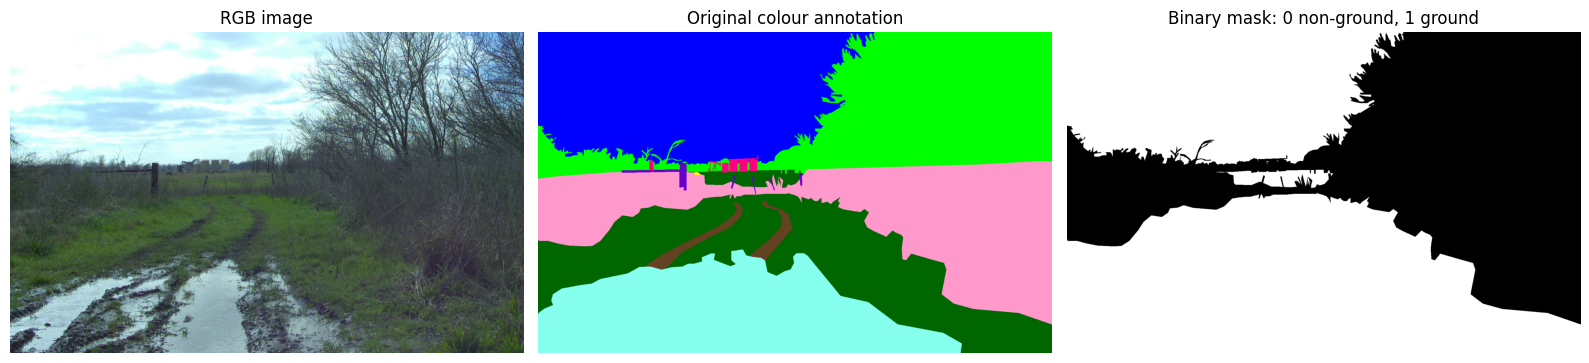

In [24]:
example_image_path, example_mask_path = pairs[0]

example_image = np.array(Image.open(example_image_path).convert('RGB'))
example_mask_rgb = np.array(Image.open(example_mask_path).convert('RGB'))
example_mask_binary = rgb_mask_to_binary(example_mask_rgb)

print('Image:', example_image_path.relative_to(IMAGE_ROOT))
print('Mask: ', example_mask_path.relative_to(MASK_ROOT))
print('Image shape:', example_image.shape)
print('Mask shape: ', example_mask_rgb.shape)
print('Binary values:', np.unique(example_mask_binary))

known_colours = set(RELLIS_COLOR_TO_ORIGINAL_ID)
observed_colours = {tuple(x) for x in unique_rgb_colours(example_mask_rgb)}
unknown_colours = sorted(observed_colours - known_colours)
print('Unknown RGB colours in this mask:', unknown_colours[:20])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(example_image)
axes[0].set_title('RGB image')
axes[1].imshow(example_mask_rgb)
axes[1].set_title('Original colour annotation')
axes[2].imshow(example_mask_binary, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Binary mask: 0 non-ground, 1 ground')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Sequence-level 70/15/15 split

The number of sequences is usually small, so exact frame percentages may differ slightly from 70/15/15. The notebook searches shuffled sequence assignments and retains the assignment whose **frame counts** best approximate the target ratios, while keeping every sequence entirely within one split.

In [25]:
from pathlib import Path

image_files = sorted(
    p for p in IMAGE_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

print("IMAGE_ROOT:", IMAGE_ROOT)
print("Number of images:", len(image_files))

for path in image_files[:10]:
    print(path.relative_to(IMAGE_ROOT))

IMAGE_ROOT: /content/RELLIS-3D/RELLIS-3D/Rellis_3D_pylon_camera_node
Number of images: 13556
Rellis-3D/00000/pylon_camera_node/frame000000-1581624652_750.jpg
Rellis-3D/00000/pylon_camera_node/frame000001-1581624652_849.jpg
Rellis-3D/00000/pylon_camera_node/frame000002-1581624652_949.jpg
Rellis-3D/00000/pylon_camera_node/frame000003-1581624653_049.jpg
Rellis-3D/00000/pylon_camera_node/frame000004-1581624653_150.jpg
Rellis-3D/00000/pylon_camera_node/frame000005-1581624653_249.jpg
Rellis-3D/00000/pylon_camera_node/frame000006-1581624653_349.jpg
Rellis-3D/00000/pylon_camera_node/frame000007-1581624653_449.jpg
Rellis-3D/00000/pylon_camera_node/frame000008-1581624653_549.jpg
Rellis-3D/00000/pylon_camera_node/frame000009-1581624653_649.jpg


In [26]:
RANDOM_SEED = 42
TARGET_RATIOS = {'train': 0.70, 'val': 0.15, 'test': 0.15}

pairs_by_sequence = defaultdict(list)
for image_path, mask_path in pairs:
    seq = sequence_name(image_path, IMAGE_ROOT)
    pairs_by_sequence[seq].append((image_path, mask_path))

sequence_counts = {seq: len(items) for seq, items in pairs_by_sequence.items()}
sequences = sorted(sequence_counts)

print('Number of sequences:', len(sequences))
print('Frames per sequence:')
for seq, count in sorted(sequence_counts.items()):
    print(f'  {seq}: {count}')

if len(sequences) < 3:
    raise RuntimeError(
        'At least three independent sequences are required for sequence-level train/val/test splitting. '
        'Do not randomly split adjacent frames unless you explicitly accept leakage.'
    )


def score_assignment(split_sequences, sequence_counts, target_ratios):
    total = sum(sequence_counts.values())
    actual = {
        split: sum(sequence_counts[s] for s in seqs) / total
        for split, seqs in split_sequences.items()
    }
    score = sum(abs(actual[s] - target_ratios[s]) for s in target_ratios)
    return score, actual


def find_sequence_split(sequences, sequence_counts, seed=42, trials=20000):
    rng = random.Random(seed)
    n = len(sequences)

    # Keep all three splits non-empty. Sequence counts are initial guides;
    # random search then optimises the resulting frame-count ratios.
    n_train = max(1, round(0.70 * n))
    n_val = max(1, round(0.15 * n))
    if n_train + n_val >= n:
        n_train = n - 2
        n_val = 1

    best = None
    for _ in range(trials):
        shuffled = list(sequences)
        rng.shuffle(shuffled)
        assignment = {
            'train': sorted(shuffled[:n_train]),
            'val': sorted(shuffled[n_train:n_train + n_val]),
            'test': sorted(shuffled[n_train + n_val:]),
        }
        if any(len(v) == 0 for v in assignment.values()):
            continue
        score, actual = score_assignment(assignment, sequence_counts, TARGET_RATIOS)
        candidate = (score, assignment, actual)
        if best is None or candidate[0] < best[0]:
            best = candidate

    if best is None:
        raise RuntimeError('Could not construct a non-empty sequence split.')
    return best[1], best[2]


split_sequences, actual_ratios = find_sequence_split(
    sequences,
    sequence_counts,
    seed=RANDOM_SEED,
)

for split in ['train', 'val', 'test']:
    frame_count = sum(sequence_counts[s] for s in split_sequences[split])
    print(f'\n{split.upper()}')
    print('Sequences:', split_sequences[split])
    print('Frames:', frame_count)
    print(f'Frame ratio: {actual_ratios[split]:.3f}')

Number of sequences: 5
Frames per sequence:
  00000: 1200
  00001: 1161
  00002: 2074
  00003: 900
  00004: 899

TRAIN
Sequences: ['00000', '00001', '00002']
Frames: 4435
Frame ratio: 0.711

VAL
Sequences: ['00003']
Frames: 900
Frame ratio: 0.144

TEST
Sequences: ['00004']
Frames: 899
Frame ratio: 0.144


## 8. Build split pair lists and save manifests

In [27]:
sequence_to_split = {
    seq: split
    for split, seqs in split_sequences.items()
    for seq in seqs
}

split_pairs = {'train': [], 'val': [], 'test': []}
for image_path, mask_path in pairs:
    seq = sequence_name(image_path, IMAGE_ROOT)
    split_pairs[sequence_to_split[seq]].append((image_path, mask_path))

for split, items in split_pairs.items():
    print(split, len(items))

# Ensure there is no sequence overlap.
assert set(split_sequences['train']).isdisjoint(split_sequences['val'])
assert set(split_sequences['train']).isdisjoint(split_sequences['test'])
assert set(split_sequences['val']).isdisjoint(split_sequences['test'])

train 4435
val 900
test 899


## 9. Process images and binary masks

Images are copied without resizing or recompression. Colour masks are converted to single-channel PNG masks containing only `0`, `1`, and `255`.

Output filenames include the relative parent path to avoid collisions when different sequences contain identical frame names.

In [28]:
OVERWRITE_OUTPUT = True

if PROCESSED_ROOT.exists() and OVERWRITE_OUTPUT:
    shutil.rmtree(PROCESSED_ROOT)


def safe_output_stem(path: Path, root: Path):
    rel = path.relative_to(root)
    parent_parts = rel.parts[:-1]
    prefix = '__'.join(parent_parts)
    return f'{prefix}__{path.stem}' if prefix else path.stem


def prepare_processed_dataset(split_pairs, processed_root: Path):
    manifest_rows = []
    unknown_colour_counter = Counter()
    pixel_counter = Counter()

    for split, items in split_pairs.items():
        image_out_dir = processed_root / 'images' / split
        mask_out_dir = processed_root / 'masks' / split
        image_out_dir.mkdir(parents=True, exist_ok=True)
        mask_out_dir.mkdir(parents=True, exist_ok=True)

        for image_path, mask_path in tqdm(items, desc=f'Processing {split}'):
            out_stem = safe_output_stem(image_path, IMAGE_ROOT)
            out_image_name = out_stem + image_path.suffix.lower()
            out_mask_name = out_stem + '.png'

            out_image_path = image_out_dir / out_image_name
            out_mask_path = mask_out_dir / out_mask_name

            shutil.copy2(image_path, out_image_path)

            mask_rgb = np.array(Image.open(mask_path).convert('RGB'))
            mask_binary = rgb_mask_to_binary(mask_rgb)
            Image.fromarray(mask_binary, mode='L').save(out_mask_path)

            # Pixel statistics.
            values, counts = np.unique(mask_binary, return_counts=True)
            for value, count in zip(values.tolist(), counts.tolist()):
                pixel_counter[int(value)] += int(count)

            observed = {tuple(x) for x in unique_rgb_colours(mask_rgb)}
            for colour in observed - set(RELLIS_COLOR_TO_ORIGINAL_ID):
                unknown_colour_counter[colour] += 1

            manifest_rows.append({
                'split': split,
                'sequence': sequence_name(image_path, IMAGE_ROOT),
                'source_image': str(image_path.relative_to(IMAGE_ROOT)),
                'source_mask': str(mask_path.relative_to(MASK_ROOT)),
                'processed_image': str(out_image_path.relative_to(processed_root)),
                'processed_mask': str(out_mask_path.relative_to(processed_root)),
            })

    manifest = pd.DataFrame(manifest_rows)
    manifest.to_csv(processed_root / 'manifest.csv', index=False)

    with open(processed_root / 'split_sequences.json', 'w') as f:
        json.dump(split_sequences, f, indent=2)

    mapping_table.to_csv(processed_root / 'binary_label_mapping.csv', index=False)

    return manifest, pixel_counter, unknown_colour_counter


manifest, pixel_counter, unknown_colour_counter = prepare_processed_dataset(
    split_pairs,
    PROCESSED_ROOT,
)

print('\nProcessed dataset saved to:', PROCESSED_ROOT)
print('Manifest rows:', len(manifest))
print('Unknown colours:', dict(unknown_colour_counter))
assert not unknown_colour_counter, 'Unknown annotation colours were found. Inspect them before using the processed data.'
manifest.head()

Processing train:   0%|          | 0/4435 [00:00<?, ?it/s]

/tmp/ipykernel_510/4188971082.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(mask_binary, mode='L').save(out_mask_path)


Processing val:   0%|          | 0/900 [00:00<?, ?it/s]

Processing test:   0%|          | 0/899 [00:00<?, ?it/s]


Processed dataset saved to: /content/RELLIS_3D_binary_processed
Manifest rows: 6234
Unknown colours: {}


,split,sequence,source_image,source_mask,processed_image,processed_mask
0,train,00000,Rellis-3D/00000/pylon_camera_node/frame000000-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...
1,train,00000,Rellis-3D/00000/pylon_camera_node/frame000002-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...
2,train,00000,Rellis-3D/00000/pylon_camera_node/frame000004-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...
3,train,00000,Rellis-3D/00000/pylon_camera_node/frame000006-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...
4,train,00000,Rellis-3D/00000/pylon_camera_node/frame000008-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...


## 10. Validate processed output

In [29]:
VALID_MASK_VALUES = {NON_GROUND_ID, GROUND_ID, IGNORE_INDEX}
validation_errors = []

for split in ['train', 'val', 'test']:
    image_dir = PROCESSED_ROOT / 'images' / split
    mask_dir = PROCESSED_ROOT / 'masks' / split

    image_files = sorted([p for p in image_dir.iterdir() if p.is_file()])
    mask_files = sorted(mask_dir.glob('*.png'))

    print(f'\n{split.upper()}')
    print('Images:', len(image_files))
    print('Masks: ', len(mask_files))

    if len(image_files) != len(mask_files):
        validation_errors.append(f'{split}: image/mask counts differ')

    for mask_path in tqdm(mask_files, desc=f'Validating {split}', leave=False):
        values = set(np.unique(np.array(Image.open(mask_path))).tolist())
        invalid = values - VALID_MASK_VALUES
        if invalid:
            validation_errors.append(f'{mask_path}: invalid values {sorted(invalid)}')

print('\nAll mask values found:', sorted(pixel_counter))
print('Validation errors:', len(validation_errors))
for error in validation_errors[:20]:
    print(error)

assert not validation_errors, 'Processed dataset validation failed.'
assert set(pixel_counter).issubset(VALID_MASK_VALUES)

valid_pixels = pixel_counter[NON_GROUND_ID] + pixel_counter[GROUND_ID]
print('\nPixel distribution:')
print(f'Non-ground (0): {pixel_counter[NON_GROUND_ID]:,} '
      f'({pixel_counter[NON_GROUND_ID] / valid_pixels:.2%} of valid pixels)')
print(f'Ground (1):     {pixel_counter[GROUND_ID]:,} '
      f'({pixel_counter[GROUND_ID] / valid_pixels:.2%} of valid pixels)')
print(f'Ignore (255):   {pixel_counter[IGNORE_INDEX]:,}')


TRAIN
Images: 4435
Masks:  4435


Validating train:   0%|          | 0/4435 [00:00<?, ?it/s]


VAL
Images: 900
Masks:  900


Validating val:   0%|          | 0/900 [00:00<?, ?it/s]


TEST
Images: 899
Masks:  899


Validating test:   0%|          | 0/899 [00:00<?, ?it/s]


All mask values found: [0, 1, 255]
Validation errors: 0

Pixel distribution:
Non-ground (0): 4,635,499,028 (45.86% of valid pixels)
Ground (1):     5,473,302,405 (54.14% of valid pixels)
Ignore (255):   4,254,334,567


## 11. Visualise processed samples from every split

In [30]:
def show_processed_samples(processed_root: Path, split: str, count=3, seed=42):
    rows = manifest[manifest['split'] == split]
    count = min(count, len(rows))
    sampled = rows.sample(n=count, random_state=seed)

    for _, row in sampled.iterrows():
        image = np.array(Image.open(processed_root / row['processed_image']).convert('RGB'))
        mask = np.array(Image.open(processed_root / row['processed_mask']))

        display_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
        display_mask[mask == NON_GROUND_ID] = (0, 0, 0)
        display_mask[mask == GROUND_ID] = (255, 255, 255)
        display_mask[mask == IGNORE_INDEX] = (127, 127, 127)

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        axes[0].imshow(image)
        axes[0].set_title(f'{split}: RGB')
        axes[1].imshow(display_mask)
        axes[1].set_title('Mask: black=non-ground, white=ground, grey=ignore')
        axes[2].imshow(image)
        axes[2].imshow(mask == GROUND_ID, alpha=0.4, cmap='Greens')
        axes[2].set_title('Ground overlay')
        for ax in axes:
            ax.axis('off')
        plt.suptitle(row['source_image'])
        plt.tight_layout()
        plt.show()

for split in ['train', 'val', 'test']:
    show_processed_samples(PROCESSED_ROOT, split, count=2)

Output hidden; open in https://colab.research.google.com to view.

## 12. Optional PyTorch dataset smoke test

This confirms that the output format can be loaded by your existing binary segmentation notebooks. It deliberately does not resize data during preprocessing; resizing and augmentation should remain in the training transform.

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader

class RELLISBinaryProcessedDataset(Dataset):
    def __init__(self, processed_root, split, transform=None):
        self.processed_root = Path(processed_root)
        self.transform = transform
        self.rows = manifest[manifest['split'] == split].reset_index(drop=True)
        if len(self.rows) == 0:
            raise RuntimeError(f'No samples found for split: {split}')

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        image = np.array(Image.open(self.processed_root / row['processed_image']).convert('RGB'))
        mask = np.array(Image.open(self.processed_root / row['processed_mask']))

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask'].long()
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()

        return image, mask

sample_dataset = RELLISBinaryProcessedDataset(PROCESSED_ROOT, 'train')
sample_image, sample_mask = sample_dataset[0]
print('Image tensor:', sample_image.shape, sample_image.dtype)
print('Mask tensor: ', sample_mask.shape, sample_mask.dtype)
print('Mask values: ', torch.unique(sample_mask))

Image tensor: torch.Size([3, 1200, 1920]) torch.float32
Mask tensor:  torch.Size([1200, 1920]) torch.int64
Mask values:  tensor([  0,   1, 255])


## 13. Zip the processed dataset and copy it to Google Drive

In [31]:
archive_base = Path('/content/RELLIS_3D_binary_processed')
archive_path = Path(shutil.make_archive(
    base_name=str(archive_base),
    format='zip',
    root_dir=str(PROCESSED_ROOT.parent),
    base_dir=PROCESSED_ROOT.name,
))

final_zip_path = DRIVE_OUTPUT_DIR / archive_path.name
shutil.copy2(archive_path, final_zip_path)

print('Local zip:', archive_path)
print('Drive zip:', final_zip_path)
print(f'Zip size: {final_zip_path.stat().st_size / (1024**3):.2f} GB')

Local zip: /content/RELLIS_3D_binary_processed.zip
Drive zip: /content/drive/MyDrive/IRP/RELLIS_3D_binary_processed.zip
Zip size: 5.06 GB


## 14. Verify the saved ZIP archive

In [32]:
import zipfile

with zipfile.ZipFile(final_zip_path, 'r') as zf:
    names = zf.namelist()

print('Number of entries:', len(names))
print('First 20 entries:')
for name in names[:20]:
    print(name)

for split in ['train', 'val', 'test']:
    image_count = sum(
        f'/images/{split}/' in f'/{name}' and not name.endswith('/')
        for name in names
    )
    mask_count = sum(
        f'/masks/{split}/' in f'/{name}' and name.lower().endswith('.png')
        for name in names
    )
    print(f'{split}: images={image_count}, masks={mask_count}, match={image_count == mask_count}')

Number of entries: 12480
First 20 entries:
RELLIS_3D_binary_processed/
RELLIS_3D_binary_processed/images/
RELLIS_3D_binary_processed/masks/
RELLIS_3D_binary_processed/binary_label_mapping.csv
RELLIS_3D_binary_processed/split_sequences.json
RELLIS_3D_binary_processed/manifest.csv
RELLIS_3D_binary_processed/images/test/
RELLIS_3D_binary_processed/images/train/
RELLIS_3D_binary_processed/images/val/
RELLIS_3D_binary_processed/images/test/Rellis-3D__00004__pylon_camera_node__frame000130-1581791691_408.jpg
RELLIS_3D_binary_processed/images/test/Rellis-3D__00004__pylon_camera_node__frame001188-1581791797_208.jpg
RELLIS_3D_binary_processed/images/test/Rellis-3D__00004__pylon_camera_node__frame000780-1581791756_408.jpg
RELLIS_3D_binary_processed/images/test/Rellis-3D__00004__pylon_camera_node__frame000226-1581791701_008.jpg
RELLIS_3D_binary_processed/images/test/Rellis-3D__00004__pylon_camera_node__frame000290-1581791707_408.jpg
RELLIS_3D_binary_processed/images/test/Rellis-3D__00004__pylon_ca

## Output structure

```text
RELLIS_3D_binary_processed/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── masks/
│   ├── train/
│   ├── val/
│   └── test/
├── manifest.csv
├── split_sequences.json
└── binary_label_mapping.csv
```

The processed masks use the same binary convention expected by the project:

- `0`: non-ground
- `1`: ground
- `255`: ignored by the loss and metrics
